In [1]:
!pip install kaggle
!pip install tensorflow keras
!pip install efficientnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import json

dataset_dir = '/content/drive/MyDrive/SoilClassification'
data = []

for class_name in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            data.append({"class": class_name, "file_path": img_path})

with open('dataset_metadata.json', 'w') as json_file:
    json.dump(data, json_file)


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [5]:
train_dir = '/content/drive/MyDrive/SoilClassification/Trains'
test_dir = '/content/drive/MyDrive/SoilClassification/Tests'

In [6]:
# Define ImageDataGenerators for loading the data
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)


In [7]:
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')


Found 3685 images belonging to 8 classes.
Found 1613 images belonging to 8 classes.


In [8]:
def build_hybrid_model():
    # Load ResNet50 and MobileNetV2 as base models
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    # Freeze base models to prevent training
    resnet.trainable = False
    mobilenet.trainable = False

    # Combine outputs of both models
    resnet_output = resnet.output
    mobilenet_output = mobilenet.output

    # Global Average Pooling
    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    # Concatenate both outputs
    combined = layers.concatenate([resnet_output, mobilenet_output])

    # Add dense layers for classification
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=[resnet.input, mobilenet.input], outputs=output)

    return model

In [9]:
# Step 6: Compile the model
hybrid_model = build_hybrid_model()
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# ResNet50 baseline
resnet_model = ResNet50(include_top=True, input_shape=(224, 224, 3), weights=None, classes=train_generator.num_classes)
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = resnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.3303 - loss: 2.9313 - val_accuracy: 0.1969 - val_loss: 2.2260
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2188 - loss: 1.7603 - val_accuracy: 0.1538 - val_loss: 2.2021
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 97s 810ms/step - accuracy: 0.4356 - loss: 1.5887 - val_accuracy: 0.2400 - val_loss: 4.4830
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.5312 - loss: 1.3830 - val_accuracy: 0.3077 - val_loss: 3.8768
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 95s 786ms/step - accuracy: 0.5227 - loss: 1.2625 - val_accuracy: 0.3381 - val_loss: 2.5542
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.5312 - loss: 1.1022 - val_accuracy: 0.0769 - val_loss: 3.2045
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 96s 793ms/step - accuracy: 0.4714 - loss: 1.4270 - val_accuracy: 0.1869 - val_loss: 10.2902
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.5000 - loss: 1.3415 -

In [7]:
# MobileNetV2 baseline
mobilenet_model = MobileNetV2(include_top=True, input_shape=(224, 224, 3), weights=None, classes=train_generator.num_classes)
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


115/115 ━━━━━━━━━━━━━━━━━━━━ 2627s 21s/step - accuracy: 0.3315 - loss: 1.8478 - val_accuracy: 0.1975 - val_loss: 2.0607
Epoch 2/10
  1/115 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.5938 - loss: 1.3073

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.5938 - loss: 1.3073 - val_accuracy: 0.0000e+00 - val_loss: 2.1166
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 746ms/step - accuracy: 0.4557 - loss: 1.4482 - val_accuracy: 0.1969 - val_loss: 2.0903
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.3750 - loss: 1.4686 - val_accuracy: 0.0769 - val_loss: 2.2190
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 88s 731ms/step - accuracy: 0.4852 - loss: 1.3036 - val_accuracy: 0.1950 - val_loss: 2.1464
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - accuracy: 0.5938 - loss: 1.1846 - val_accuracy: 0.3077 - val_loss: 2.0312
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 88s 725ms/step - accuracy: 0.5134 - loss: 1.2433 - val_accuracy: 0.1950 - val_loss: 2.1963
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - accuracy: 0.5625 - loss: 1.0505 - val_accuracy: 0.3077 - val_loss: 1.9218
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 88s 730ms/step - accuracy: 0.5410 - loss: 1.1996 - va

In [8]:
def build_hybrid_model():
    # Load ResNet50 and MobileNetV2 as base models
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    # Freeze base models to prevent training
    resnet.trainable = False
    mobilenet.trainable = False

    # Use one input tensor for both models
    input_tensor = layers.Input(shape=(224, 224, 3))

    # Pass the input to both models
    resnet_output = resnet(input_tensor)
    mobilenet_output = mobilenet(input_tensor)

    # Global Average Pooling
    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    # Concatenate both outputs
    combined = layers.concatenate([resnet_output, mobilenet_output])

    # Add dense layers for classification
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=input_tensor, outputs=output)

    return model


In [9]:
# Compile the hybrid model
hybrid_model = build_hybrid_model()
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the hybrid model (No need to pass two data generators)
history_hybrid = hybrid_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 118s 832ms/step - accuracy: 0.4212 - loss: 1.6921 - val_accuracy: 0.6431 - val_loss: 1.0049
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5312 - loss: 1.1777 - val_accuracy: 0.8462 - val_loss: 0.6711
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 90s 750ms/step - accuracy: 0.6757 - loss: 0.9777 - val_accuracy: 0.6531 - val_loss: 0.9432
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7188 - loss: 0.8824 - val_accuracy: 0.5385 - val_loss: 1.1514
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 88s 733ms/step - accuracy: 0.7120 - loss: 0.8006 - val_accuracy: 0.6775 - val_loss: 0.8897
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.6875 - loss: 0.7063 - val_accuracy: 0.8462 - val_loss: 0.5605
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 141s 731ms/step - accuracy: 0.7347 - loss: 0.7463 - val_accuracy: 0.7481 - val

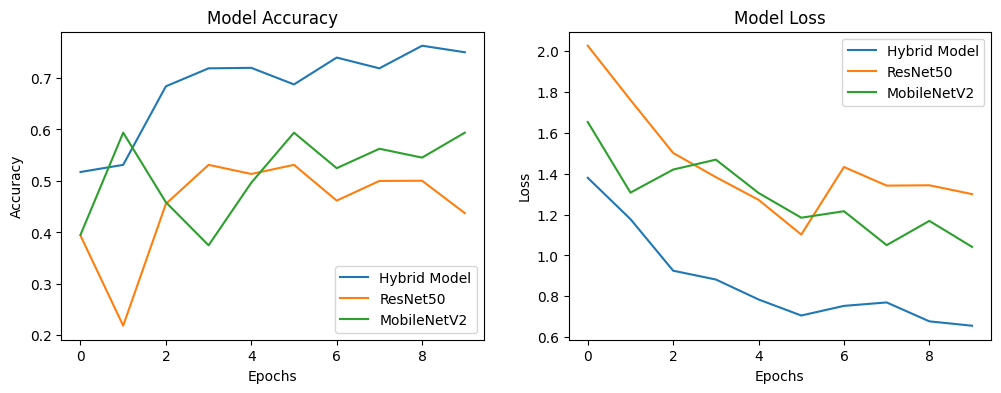

In [12]:
# Step 9: Compare the hybrid model with the baseline models

# Plot the accuracy and loss for comparison
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'], label='Hybrid Model')
plt.plot(history_resnet.history['accuracy'], label='ResNet50')
plt.plot(history_mobilenet.history['accuracy'], label='MobileNetV2')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='Hybrid Model')
plt.plot(history_resnet.history['loss'], label='ResNet50')
plt.plot(history_mobilenet.history['loss'], label='MobileNetV2')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [13]:
# Step 10: Evaluate the hybrid model
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(test_generator)
print(f'Hybrid Model Accuracy: {hybrid_accuracy:.2f}')


51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 310ms/step - accuracy: 0.7458 - loss: 0.7298
Hybrid Model Accuracy: 0.74


In [14]:
import pandas as pd

# Step 8: Evaluate the Models and Collect Data

# Evaluate MobileNetV2
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_generator)
print(f'MobileNetV2 Accuracy: {mobilenet_accuracy:.2f}')

# Evaluate ResNet50
resnet_loss, resnet_accuracy = resnet_model.evaluate(test_generator)
print(f'ResNet50 Accuracy: {resnet_accuracy:.2f}')

# Evaluate Hybrid Model
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(test_generator)
print(f'Hybrid Model Accuracy: {hybrid_accuracy:.2f}')

# Step 9: Store results in a table (Pandas DataFrame)

comparison_data = {
    'Model': ['MobileNetV2', 'ResNet50', 'Hybrid Model'],
    'Test Accuracy': [mobilenet_accuracy, resnet_accuracy, hybrid_accuracy],
    'Test Loss': [mobilenet_loss, resnet_loss, hybrid_loss]
}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the table
print("\nComparison of Model Performance:")
comparison_df


51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.1991 - loss: 2.2019
MobileNetV2 Accuracy: 0.20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.1836 - loss: 5.9330
ResNet50 Accuracy: 0.17
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 312ms/step - accuracy: 0.7405 - loss: 0.7620
Hybrid Model Accuracy: 0.74

Comparison of Model Performance:


,Model,Test Accuracy,Test Loss
0,MobileNetV2,0.195908,2.212811
1,ResNet50,0.168010,6.154647
2,Hybrid Model,0.736516,0.742642


**Enhancing the model**

In [31]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [32]:
# Define Hybrid Model (Enhanced Version)
def build_enhanced_hybrid_model():
    # Load ResNet50 and MobileNetV2 as base models
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    # Unfreeze the last few layers for fine-tuning
    for layer in resnet.layers[-10:]:
        layer.trainable = True
    for layer in mobilenet.layers[-10:]:
        layer.trainable = True

    # Define the input
    input_tensor = layers.Input(shape=(224, 224, 3))

    # Pass input to both models
    resnet_output = resnet(input_tensor)
    mobilenet_output = mobilenet(input_tensor)

    # Global Average Pooling
    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    # Concatenate the outputs from both models
    combined = layers.concatenate([resnet_output, mobilenet_output])

    # Add dense layers with Batch Normalization and Dropout
    x = layers.Dense(512, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    # Create model
    model = models.Model(inputs=input_tensor, outputs=output)

    return model

In [33]:
# Compile the enhanced hybrid model
enhanced_hybrid_model = build_enhanced_hybrid_model()
enhanced_hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [35]:
# Step 7: Add Learning Rate Scheduler and Early Stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [48]:
# Train the enhanced hybrid model
history_enhanced_hybrid = enhanced_hybrid_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=20,  # Train for more epochs
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 106s 887ms/step - accuracy: 0.9031 - loss: 0.3385 - val_accuracy: 0.4431 - val_loss: 2.4800 - learning_rate: 2.0000e-04
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8750 - loss: 0.2802 - val_accuracy: 0.5385 - val_loss: 1.5331 - learning_rate: 2.0000e-04
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 110s 905ms/step - accuracy: 0.9027 - loss: 0.2941 - val_accuracy: 0.4700 - val_loss: 2.3722 - learning_rate: 2.0000e-04
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 1.0000 - loss: 0.0676 - val_accuracy: 0.4615 - val_loss: 2.6510 - learning_rate: 2.0000e-04
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9230 - loss: 0.2626 - val_accuracy: 0.4269 - val_loss: 2.3161 - learning_rate: 2.0000e-04
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.8125 - loss: 0.5501 - val_accuracy: 0.3077 - val_loss: 2.7042 - learning_rate: 4.0000e-05
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/ste

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
test_loss, test_accuracy = enhanced_hybrid_model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Accuracy: {test_accuracy}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 309ms/step - accuracy: 0.3141 - loss: 3.1210
Test Accuracy: 0.31312501430511475


In [38]:
# Step 2: Generate predictions (these will be probabilities, so we'll need to convert them to class labels)
y_pred_prob = enhanced_hybrid_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size)
y_pred = np.argmax(y_pred_prob, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 283ms/step


In [39]:
# Step 3: Get true labels from the test generator
y_true = test_generator.classes  # True labels from the test data


In [40]:
# Run predict, making sure to convert steps to an integer
y_pred_prob = enhanced_hybrid_model.predict(test_generator, steps=int(np.ceil(test_generator.samples / test_generator.batch_size)))
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

# Ensure y_true has the correct number of samples
y_true = test_generator.classes[:len(y_pred)]  # Adjust the size of y_true if necessary

51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 409ms/step


In [41]:
# Step 3: Calculate Accuracy, Precision, Recall, and F1-Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')  # Adjust 'average' for multi-class
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')


In [42]:
# Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Accuracy: 0.11903285802851829
Precision: 0.13273641667046
Recall: 0.11903285802851829
F1-Score: 0.09070836501612643


In [43]:
# Evaluate the enhanced hybrid model
enhanced_hybrid_loss, enhanced_hybrid_accuracy = enhanced_hybrid_model.evaluate(test_generator)
print(f'Enhanced Hybrid Model Accuracy: {enhanced_hybrid_accuracy:.2f}')


51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 313ms/step - accuracy: 0.3070 - loss: 3.2817
Enhanced Hybrid Model Accuracy: 0.31


In [44]:
# Step 9: Compare with previous models
comparison_data = {
    'Model': ['MobileNetV2', 'ResNet50', 'Hybrid Model', 'Enhanced Hybrid Model'],
    'Test Accuracy': [mobilenet_accuracy, resnet_accuracy, hybrid_accuracy, enhanced_hybrid_accuracy],
    'Test Loss': [mobilenet_loss, resnet_loss, hybrid_loss, enhanced_hybrid_loss]
}


In [45]:
# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)


In [46]:
# Display the table
print("\nComparison of Model Performance:")
comparison_df


Comparison of Model Performance:


,Model,Test Accuracy,Test Loss
0,MobileNetV2,0.783013,0.693982
1,ResNet50,0.316181,1.721764
2,Hybrid Model,0.744575,0.761551
3,Enhanced Hybrid Model,0.313701,3.233734


**Automatic Crop Recommendation System**

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [10]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 3685 images belonging to 8 classes.
Found 1613 images belonging to 8 classes.


In [11]:
# Step 2: Define Baseline Models and Hybrid Model

# Define MobileNetV2 Model
def build_mobilenet_model():
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet.trainable = False

    x = mobilenet.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=mobilenet.input, outputs=output)
    return model

# Define ResNet50 Model
def build_resnet_model():
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    resnet.trainable = False

    x = resnet.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=resnet.input, outputs=output)
    return model

# Define Hybrid Model
def build_hybrid_model():
    resnet = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    mobilenet = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

    resnet.trainable = False
    mobilenet.trainable = False

    input_tensor = layers.Input(shape=(224, 224, 3))
    resnet_output = resnet(input_tensor)
    mobilenet_output = mobilenet(input_tensor)

    resnet_output = layers.GlobalAveragePooling2D()(resnet_output)
    mobilenet_output = layers.GlobalAveragePooling2D()(mobilenet_output)

    combined = layers.concatenate([resnet_output, mobilenet_output])

    x = layers.Dense(256, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

    model = models.Model(inputs=input_tensor, outputs=output)

    return model

In [12]:
# Step 3: Compile the Models

mobilenet_model = build_mobilenet_model()
resnet_model = build_resnet_model()
hybrid_model = build_hybrid_model()

mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hybrid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Step 4: Train the Models

In [13]:
# Train MobileNetV2 Model
history_mobilenet = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


115/115 ━━━━━━━━━━━━━━━━━━━━ 2259s 19s/step - accuracy: 0.4240 - loss: 1.6935 - val_accuracy: 0.6494 - val_loss: 0.9674
Epoch 2/10
  1/115 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5625 - loss: 1.0663

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


115/115 ━━━━━━━━━━━━━━━━━━━━ 45s 397ms/step - accuracy: 0.5625 - loss: 1.0663 - val_accuracy: 0.8462 - val_loss: 0.7393
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 88s 722ms/step - accuracy: 0.6907 - loss: 0.8916 - val_accuracy: 0.7256 - val_loss: 0.7934
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6250 - loss: 1.1151 - val_accuracy: 0.6154 - val_loss: 1.2153
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 89s 739ms/step - accuracy: 0.7372 - loss: 0.7645 - val_accuracy: 0.7506 - val_loss: 0.7603
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7812 - loss: 0.5821 - val_accuracy: 0.7692 - val_loss: 0.6445
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 135s 731ms/step - accuracy: 0.7650 - loss: 0.6627 - val_accuracy: 0.7119 - val_loss: 0.8484
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - accuracy: 0.6562 - loss: 0.8467 - val_accuracy: 0.8462 - val_loss: 0.5209
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 148s 776ms/step - accuracy: 0.8005 - loss: 0.5765 - val_ac

In [14]:
# Train ResNet50 Model
history_resnet = resnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 118s 865ms/step - accuracy: 0.2044 - loss: 2.0914 - val_accuracy: 0.2937 - val_loss: 1.7878
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.2188 - loss: 1.7368 - val_accuracy: 0.3077 - val_loss: 1.6958
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 92s 771ms/step - accuracy: 0.2809 - loss: 1.8356 - val_accuracy: 0.3231 - val_loss: 1.7672
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.1562 - loss: 2.0575 - val_accuracy: 0.3077 - val_loss: 1.6056
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 141s 759ms/step - accuracy: 0.2873 - loss: 1.8197 - val_accuracy: 0.3131 - val_loss: 1.7392
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.3438 - loss: 1.4490 - val_accuracy: 0.4615 - val_loss: 1.5268
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 94s 770ms/step - accuracy: 0.3001 - loss: 1.7959 - val_accuracy: 0.3050 - val_loss: 1.7713
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - accuracy: 0.2812 - loss: 1.735

In [15]:
# Train Hybrid Model
history_hybrid = hybrid_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 123s 881ms/step - accuracy: 0.4077 - loss: 1.8033 - val_accuracy: 0.6062 - val_loss: 1.0293
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 192ms/step - accuracy: 0.7188 - loss: 0.8872 - val_accuracy: 0.5385 - val_loss: 1.0408
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 101s 765ms/step - accuracy: 0.6680 - loss: 0.9518 - val_accuracy: 0.7056 - val_loss: 0.8109
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.6250 - loss: 0.9699 - val_accuracy: 0.7692 - val_loss: 0.6187
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 90s 751ms/step - accuracy: 0.7191 - loss: 0.8100 - val_accuracy: 0.6969 - val_loss: 0.8300
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.8750 - loss: 0.4441 - val_accuracy: 0.7692 - val_loss: 0.7148
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 146s 785ms/step - accuracy: 0.7323 - loss: 0.7590 - val_accuracy: 0.7275 - val_loss: 0.7587
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.8125 - loss: 0

# Step 5: Crop Recommendation System Based on Soil Type

In [16]:
# Assuming soil types are labeled as 'Clay', 'Loam', 'Sandy', etc.
soil_to_crop = {
    'Clay': 'Rice, Wheat, Soybean',
    'Loam': 'Vegetables, Corn, Beans',
    'Sandy': 'Potatoes, Carrots, Watermelon',
    'Silty': 'Peas, Lentils, Fruits',
    'Peaty': 'Cranberries, Blueberries'
}

def recommend_crop(soil_label):
    return soil_to_crop.get(soil_label, "Crop not available for this soil type")

** Step 6: Evaluation and Automatic Crop Recommendation
**

In [17]:
# Evaluate MobileNetV2
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_generator)
print(f'MobileNetV2 Accuracy: {mobilenet_accuracy:.2f}')


51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.7739 - loss: 0.7264
MobileNetV2 Accuracy: 0.78


In [18]:
# Evaluate ResNet50
resnet_loss, resnet_accuracy = resnet_model.evaluate(test_generator)
print(f'ResNet50 Accuracy: {resnet_accuracy:.2f}')


51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 343ms/step - accuracy: 0.3304 - loss: 1.7207
ResNet50 Accuracy: 0.32


In [19]:
# Evaluate Hybrid Model
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(test_generator)
print(f'Hybrid Model Accuracy: {hybrid_accuracy:.2f}')


51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 308ms/step - accuracy: 0.7554 - loss: 0.7499
Hybrid Model Accuracy: 0.74


# Step 7: Test the Automatic Crop Recommendation System


In [21]:
# Get a batch of test images
images, labels = next(test_generator)
predicted_labels = hybrid_model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [23]:
# Convert predictions into soil types
class_indices_keys = list(train_generator.class_indices.keys())
predicted_soil_types = [class_indices_keys[np.argmax(pred)] for pred in predicted_labels]

In [24]:
# Recommend crops based on predicted soil types
for i, soil_type in enumerate(predicted_soil_types):
    print(f"Predicted Soil Type: {soil_type}, Recommended Crops: {recommend_crop(soil_type)}")


Predicted Soil Type: Mary, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Red soil, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Red soil, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Alluvial soil, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Silt, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Red soil, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Red soil, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Chalky, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Silt, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Black, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Silt, Recommended Crops: Crop not available for this soil type
Predicted Soil Type: Clay soil, Recommended Crop